# Questão 2. Regressão Polinomial

Suponha que $m \geq d+1$. Defina a função $R_{X,d} : \mathbb R^m \to \mathcal P_d$ que associa a cada vetor $b \in \mathbb R^m$ o polinômio $p \in \mathcal P_d$ que melhor se ajusta aos valores $b_i$ (nos pontos $x_i \in X$) no sentido de mínimos quadrados, ou seja, $\argmin_{p \in \mathcal P_d}\left\|L_X(p) - b\right\|_2^2$.


## Letra (a):

Mostre que $R_{X,d}$ é uma inversa à esquerda de $L_X$, ou seja, $R_{X,d}\circ L_X = \text{id}_{\mathcal P_d}$.

Note que $(R_{X,d}\circ L_X)(p) = R_{X,d}(L_X(p)) = \argmin_{q \in \mathcal P_d}\left\|L_X(q) - L_X(p)\right\|_2^2 = \argmin_{q \in \mathcal P_d}\left\|L_X(q - p)\right\|_2^2$. Analisando a função $\left\|L_X(q - p)\right\|_2^2$, como $L_X$ é uma transformação linear (questão 1), $L_X(0) = 0$. Portanto, $q = p$ minimiza a função $\left\|L_X(q - p)\right\|_2^2$, o que implica em 
$$R_{X_d}(L_X(p)) = p.$$

## Letra (b):

Se convença que $R_{X,d}$ é uma transformação linear.

In [117]:
using LinearAlgebra

function R_Xd_manual(X, d, b)
    m = length(X)
    V = zeros(m, d+1)
    for i in 1:m
        for j in 0:d
            V[i, j+1] = X[i]^j
        end
    end
    c = V \ b   # resolve min ||Vc - b||_2
    return c
    # return x -> sum(c[j+1] * x^j for j in 0:d)
end

function teste_linearidade()

    println("#=== Variando o grau dos polinômios ===#")
    println("# teste R_Xd(a + b) = R_Xd(a) + R_Xd(b):")
    for d in 5:10
        println("# Teste com polinômios de grau $d")
        x = rand(1:10, (d + 2))
        a = rand(1:10, (d + 2))
        b = rand(1:10, (d + 2))
        
        r1 = R_Xd_manual(x, d, a)
        r2 = R_Xd_manual(x, d, b)
        r3 = R_Xd_manual(x, d, (a + b))

        if (norm((r3 - r2 - r1)) < 1e-10)
            println("True")
        else
            println("False")
        end

    end

    println("\n\n#=== teste R_Xd(ka) = k R_Xd(a) ===#")
    for d in 5:10
        println("# Teste com polinômios de grau $d")
        x = rand(1:10, (d + 2))
        a = rand(1:10, (d + 2))
        c = rand(1:10)
        
        r1 = R_Xd_manual(x, d, a)
        r2 = R_Xd_manual(x, d, (c*a))
        
        if (norm((r2 - c * r1)) < 1e-10)
            println("True")
        else
            println("False")
        end

    end

    println("\n#=== Variando o total de pontos ===#\n")
    for pts in 10:15
        println("# Teste com $pts pontos")
        x = rand(1:10, pts)
        a = rand(1:10, pts)
        b = rand(1:10, pts)
        a1 = rand(1:10)
        b1 = rand(1:10)

        r1 = R_Xd_manual(x, 8, a)
        r2 = R_Xd_manual(x, 8, b)
        r3 = R_Xd_manual(x, 8, (a1 * a + b1 * b))

        if(norm((r3 - a1 * r1 - b1 * r2)) < 1e-10)
            println("True")
        else
            println("False")
        end

    end
end

teste_linearidade()


#=== Variando o grau dos polinômios ===#
# teste R_Xd(a + b) = R_Xd(a) + R_Xd(b):
# Teste com polinômios de grau 5
True
# Teste com polinômios de grau 6
True
# Teste com polinômios de grau 7
True
# Teste com polinômios de grau 8
True
# Teste com polinômios de grau 9
True
# Teste com polinômios de grau 10
True


#=== teste R_Xd(ka) = k R_Xd(a) ===#
# Teste com polinômios de grau 5
True
# Teste com polinômios de grau 6
True
# Teste com polinômios de grau 7
True
# Teste com polinômios de grau 8
True
# Teste com polinômios de grau 9
True
# Teste com polinômios de grau 10
True

#=== Variando o total de pontos ===#

# Teste com 10 pontos
True
# Teste com 11 pontos
True
# Teste com 12 pontos
True
# Teste com 13 pontos
True
# Teste com 14 pontos
True
# Teste com 15 pontos
True


Para implementar $R_{X,d}$, utilizamos da função solve ('\\') em julia que resolve o problema de mínimos quadrados, e escrevemos $L_X(p) = Vc$, onde $V$ é a matriz de Vandermonde de $X$, que representa $L_X$ quando $p$ está sendo representado por um vetor na base canônica de $\mathcal P_d$, no caso, o vetor $c$ (vetor $d+1$-dimensional de coeficientes de $p$), como foi visto na questão 1.

Todos os testes que fizemos indicam que $R_{X, d}$ é uma transformação linear. Vamos provar matematicamente que isso está de fato correto.
Como $m \ge d + 1$, então $L_X$ é injetiva. Se $L_X(p) = L_X(q)$, $$L_X(p - q) = 0 \Rightarrow ((p - q)(x_1), ..., (p - q)(x_m)) = 0$$
Logo, $(p - q)$ é um polinômio de grau $d$ com $m \ge d + 1$, então $(p - q)$ é polinômio nulo, então $p = q$, provando a injetividade. Para $b \in \mathbb{R}^m$, o que $R_{X, d}(b)$ faz? Ele encontra o polinômio $p$ tal que $(p(x_1), ..., p(x_m)) \in Im(L_X)$ esteja o mais próximo possível de $b$. Seja $V_{T}$ a projeção ortogonal no espaço $T = Im(L_X)$. Então $$V_T(b) = L_X(R_{X, d}(b))$$ Como a projeção ortogonal é linear, $$L_X(R_{X, d}(\alpha a + \beta b)) = V_T(\alpha a + \beta b) = \alpha V_T(a) + \beta V_T(b) = \alpha L_X(R_{X, d}(a)) + \beta L_X(R_{X, d}(b))$$ Como $L_X$ também é linear, segue que $$L_X(R_{X, d}(\alpha a + \beta b)) = \alpha L_X(R_{X, d}(a)) + \beta L_X(R_{X, d}(b)) = L_X(\alpha R_{X, d}(a) + \beta R_{X, d}(b))$$ Pela injetividade de $L_X$, temos que $$R_{X, d}(\alpha a + \beta b) = \alpha R_{X, d}(a) + \beta R_{X, d}(b).$$

## Letra (c):

Como calcular a matrix de $R_{X, d}$ na base canônica de $\mathcal P_d$?

A base canônica de $\mathcal P_d$ é dada por $\left\{1, x, x^2,\dots, x^d\right\}$. Como visto anteriormente e na questão 1, 
$$L_X(p) = Vc, \text{ onde } V = \begin{bmatrix} 1 & x_1 & \cdots & x_1^d \\ 1 & x_2 & \cdots & x_2^d \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_m & \cdots & x_m^d\end{bmatrix},$$

e $c = \begin{bmatrix} c_0 & c_1 & \cdots & c_d\end{bmatrix}^T$ é o vetor de coeficientes de $p$. Logo, temos que 
$$R_{X,d}(b)= \argmin_{c \in \mathbb R^{d+1}}\left\|Vc - b\right\|_2^2.$$

Para minimizar $\left\|Vc - b\right\|_2^2$, o vetor $Vc - b$ deve ser ortogonal ao espaço coluna de $V$. Isso nos leva a

$$V^T(Vc - b) = 0 \Rightarrow V^TVc = V^Tb.$$
Como $V$ tem posto completo (questão 1 letra (d)), sabemos que $V^TV$ é simétrica e positiva definida. De fato, note que 
$$x^T(V^TV)x = \left<Vx, Vx\right> = \left\|Vx\right\|_2^2 = 0 \iff Vx = 0 \iff x = 0.$$
Logo, $V^TV$ é invertível, e temos que
$$c = (V^TV)^{-1}V^Tb,$$
isto é, $R_{X,d} = (V^TV)^{-1}V^T$.


## Letra (d):

$\textbf{Condicionamento.}$ Escolha alguns valores de $m$ e $d$ e calcule os números de condicionamento das matrizes $L_X$ e $R_{X,d}$ na base canônica de $\mathcal P_d$. Como o número de condicionamento das matrizes $L_X$ e $R_{X,d}$ se comporta conforme $m$ e/ou $d$ aumentam?

Lema: O condicionamento da matriz de $R_{X,d}$ é igual ao condicionamento da matriz de $L_{X}$

$L_{X}$ na base canônica de $\mathcal P_d$ é a matriz $V$ de vandermonde, onde $V_{ij} = x_{i}^{j-1}$. Também,
$R_{X,d}$ é a pseudo-inversa da matriz de $L_{X}$, ou seja, $(V^{T}V)^{-1}V^{T} = V^\dagger$. Seja $s_{1}, \dots, s_{n}$
os valores singulares de $V$, com $s_{1} \geq s_{2} \geq \dots \geq s_{n}$. Então existem listas ortonormais $e_{1}, \dots, e_{n}$ e $f_{1}, \dots, f_{n}$
tais que:
$$Vu = s_{1}\left\langle u, e_{1} \right\rangle f_{1} + ... + s_{n} \left\langle u, e_{n} \right\rangle f_{n}$$
e
$$V^\dagger u = \frac{\left\langle u, f_{1} \right\rangle}{s_{1}} e_{1} + ... + \frac{\left\langle u, f_{n} \right\rangle}{s_{n}} e_{n}$$

Sabemos que o condicionamento de uma matriz é o maior valor singular dividido pelo menor. Então
$$\kappa(V) = \frac{s_{1}}{s_{n}}$$
Enquanto isso, o maior valor singular de $V^\dagger$ é $\frac{1}{s_{n}}$, enquanto o menor é $\frac{1}{s_{1}}$. Logo,
$$\kappa(V^\dagger) = \frac{\frac{1}{s_{n}}} {\frac{1}{s_{1}}} = \frac{s_{1}}{s_{n}} = \kappa(V).$$

Logo, os condicionamentos são iguais
Desse modo, basta analisar o comportamento do condicionamento da matriz de $L_{X}$ quando $d$ e $m$ variam, 
pois este será igual ao da matriz de $R_{X,d}$.


In [118]:
using Plots
using PGFPlotsX
using LaTeXStrings

push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")

pgfplotsx()


function matrix_vandermonde(X, d)
    m = length(X)
    V = zeros(Float64, m, d+1)
    for i in 1:m
        for j in 1:d+1
            V[i, j] = X[i]^(j-1)
        end
    end
    return V
end

function plot_conditioning_canonical(d_max=25)
    degrees = 2:d_max
    
    cond_uni_exact  = Float64[]
    cond_uni_over   = Float64[]
    
    for d in degrees
        push!(cond_uni_exact,  cond(matrix_vandermonde(range(-1.0, 1.0, length=d+1), d)))
        m_over = 2 * d
        push!(cond_uni_over,   cond(matrix_vandermonde(range(-1.0, 1.0, length=m_over), d)))
    end
    
    p = plot(title="Condicionamento: Base Canônica",
             xlabel=L"\text{Grau do Polinômio }(d)", 
             ylabel=L"\text{Número de Condicionamento } \kappa \text{ (Log)}",
             yscale=:log10, 
             legend=:topleft,
             grid=true,
             size=(800, 600),
             margin=5Plots.mm)
             
    plot!(p, degrees, cond_uni_exact,  label=L"\text{Uniforme Quadrada } (m = d+1)", lw=2, marker=:circle, color=:blue)
    plot!(p, degrees, cond_uni_over,   label=L"\text{Uniforme Over }(m = 2d)", lw=2, ls=:dash, marker=:circle, color=:red)

    return p
end

plot_conditioning_canonical()

ArgumentError: ArgumentError: Package PGFPlotsX not found in current path.
- Run `import Pkg; Pkg.add("PGFPlotsX")` to install the PGFPlotsX package.

## Letra (e)

Calcule as matrizes de $L_X$ e $R_{X,d}$ usando a base dos polinômios interpoladores de Lagrange. Qual o condicionamento das matrizes $L_X$ e $R_{X,d}$ nestas bases?

As colunas das matrizes correspondem a aplicação das transformações nos vetores base. Isto é, $L_X = \begin{bmatrix} L_X^1 & L_X^2 & \cdots & L_X^{d+1}\end{bmatrix}$, onde
$$L_X^j = L_X(p_j) = \begin{bmatrix} p_j(x_1) \\ \vdots \\ p_j(x_{d+1}) \\ p_j(x_{d+2}) \\ \vdots \\ p_j(x_m) \end{bmatrix} = \begin{bmatrix} \delta_{1j} \\ \vdots \\ \delta_{(d+1)j} \\ p_j(x_{d+2}) \\ \vdots \\ p_j(x_m)\end{bmatrix}.$$

Logo, se $\ell = \left\{p_1,p_2,\dots,p_{d+1}\right\}$ é a base de dos polinômios interpoladores de Lagrange, temos que 
$$M_L := [L_X]_\ell = \begin{bmatrix} I_{d+1} \\ P\end{bmatrix},$$
onde $P$ é a matriz $(m- d - 1)\times (d+1)$ com as avaliações dos polinômios nos pontos "extras".

Como $R_{X,d}$ é a pseudo-inversa de $L_X$ (letra (c)), temos que a matriz $R_{X,d}$ na base de Lagrange é
$$T := [R_{X,d}]_\ell = (M_L^TM_L)^{-1}M_L^T.$$

Note que
$$M_L^TM = \begin{bmatrix} I_{d+1} & P^T\end{bmatrix}\begin{bmatrix} I_{d+1} \\ P\end{bmatrix} = I_{d+1} + P^TP.$$

Assim,
$$T = (I_{d+1} + P^TP)^{-1}\begin{bmatrix} I_{d+1} & P^T\end{bmatrix}.$$

Para analisar o condicionamento das matrizes nestas bases, basta observar o condicionamento de $M_L$, pois $\kappa(M_L) = \kappa(T)$ (letra (d)).

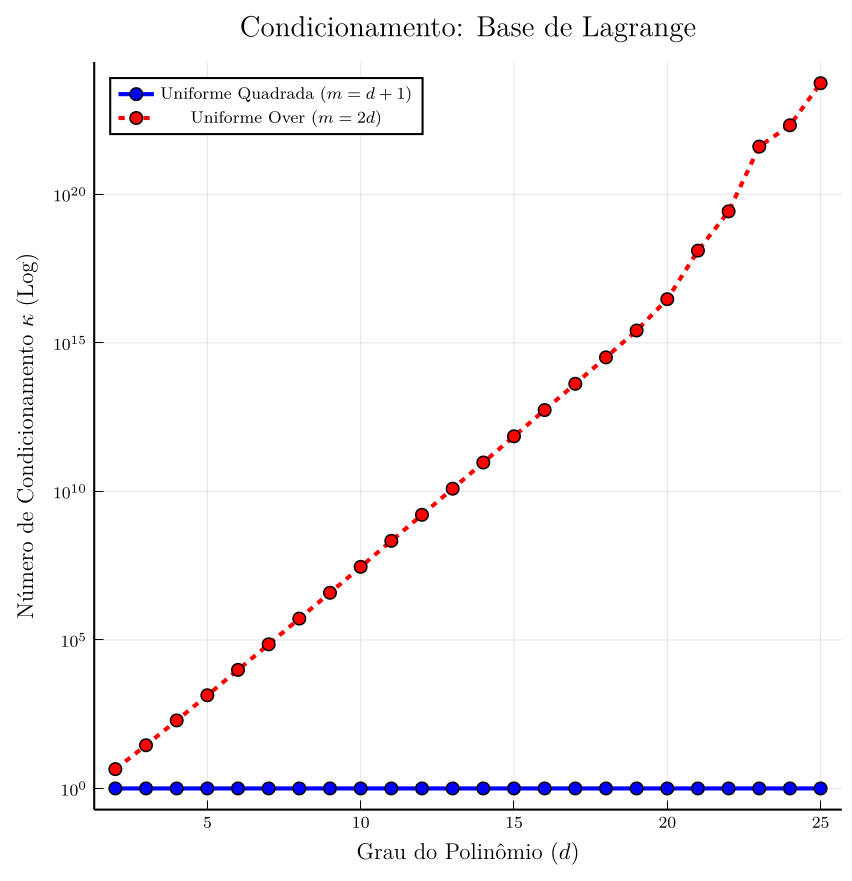

In [119]:
function denominator_lagrange(X, j, d)
    val = 1.0
    for k in 1:d+1
        if k != j
            val *= X[j] - X[k]
        end
    end
    return 1 / val
end

function lagrange_base_eval(X, x, j, d, D)
    val = D 
    for k in 1:d+1
        if k != j
            val *= (x - X[k])
        end
    end
    return val
end

function matrix_lagrange(X, d)
    m = length(X)
    M_L = zeros(Float64, m, d + 1)
    
    for i in 1:(d + 1)
        M_L[i, i] = 1.0
    end

    if m == d + 1
        return M_L
    end

    X_base = @view X[1:d+1]

    for j in 1:(d + 1)
        D = denominator_lagrange(X_base, j, d)
        for i in (d+2):m
            M_L[i, j] = lagrange_base_eval(X_base, X[i], j, d, D)
        end
    end

    return M_L
end


function plot_conditioning(d_max=25)
    degrees = 2:d_max
    
    cond_uni_exact  = Float64[]
    cond_uni_over   = Float64[]
    
    for d in degrees
        push!(cond_uni_exact,  cond(matrix_lagrange(range(-1.0, 1.0, length=d+1), d)))
        m_over = 2 * d
        push!(cond_uni_over,   cond(matrix_lagrange(range(-1.0, 1.0, length=m_over), d)))
    end
    
    p = plot(title="Condicionamento: Base de Lagrange",
             xlabel=L"\text{Grau do Polinômio } (d)", 
             ylabel=L"\text{Número de Condicionamento }\kappa \text{ (Log)}",
             yscale=:log10, 
             legend=:topleft,
             grid=true,
             size=(600, 600),
             margin=5Plots.mm)
             
    plot!(p, degrees, cond_uni_exact,  label=L"\text{Uniforme Quadrada } (m = d+1)", lw=2, marker=:circle, color=:blue)
    plot!(p, degrees, cond_uni_over,   label=L"\text{Uniforme Over }(m = 2d)", lw=2, ls=:dash, marker=:circle, color=:red)
    
    return p
end

plot_conditioning(25)



## Letra (f):

Compare a complexidade computacional de calcular $L_X$ e $R_{X,d}$ usando as bases canônica e de Lagrange com o condicionamento das matrizes.

### Complexidade na Base Canônica:
#### $L_X$
A complexidade para se calcular a matriz $V$ de $L_{X}$ é $O(md)$, pois, dado o conjunto $X = \left\{x_{1}, ..., x_{m}\right\}$
de pontos, calculamos as $m(d + 1)$ entradas da matriz, cada uma com custo $O(1)$ pois $V_{ij} = x_{i}^{j - 1}$ é
uma exponenciação de custo $O(1)$.

#### $R_{X, d}$
Para a matriz $V^\dagger$ de $R^{X, d}$, a complexidade é $min\{O(md^2), O(m^2d)\} = O(md^2)$ e pode ser computada de por algoritmos estáveis de $QR$ e $SVD$. Porém, em muitas aplicações não é necessário calcular a pseudoinversa diretamente. Quando você quer calcular os coeficientes do polinômio que melhor se ajustam a um conjunto de valores, usar simplesmente $c = V \backslash b$ é muito melhor! 

Para calcular o condicionamento de $V^\dagger$ também não é necessário computá-la diretamente. Como provado, seu condicionamento é igual ao de $V$. Por isso, basta calcular $k(V)$, muito menos custoso e muito mais preciso do que fazer $(V^TV)^{-1}V^T$ e só então achar $k(V^\dagger)$


### Complexidade na Base de Lagrange:
#### $L_{X}$: Caso específico
O custo computacional para calcular a matriz de $L_{X}$ na base de lagrange é $O(d^{2}m)$. A $j$-ésima coluna da matriz $L$
de $L_{X}$ é $L_{X}(p_{j})$, $L_{X}$ aplicado no $j$-ésimo polinômio da base de lagrange. Quando usamos uma base conveninte em que $p_{j}(x_{i}) = \delta_{ij}$ para
$1 \leq i \leq d + 1, 1 \leq j \leq d + 1$, então o bloco $(d + 1) \times (d + 1)$ superior de $L$ será a identidade. Se $m = d + 1$, então
$L$ é simplesmente a identidade (e $R_{X, d}$ também será!), um resultado muito bonito pois o condicionamento será 1,
o condicionamento perfeito. Porém, quando $m > d + 1$, teremos um bloco $(m - d - 1) \times (d + 1)$ de valores que a priore
não temos muitas informações. O que sabemos é que $L_{ij} = p_{j}(x_{i})$ para $m \geq i \geq d + 2$.

Para colocar as $d + 1$ entradas 1 na diagonal do bloco identidade, são necessárias $d + 1$ operações. Se $m = (d + 1)$, $L$ é simplesmente a identidade e a complexidade é $O(d)$.
Para calcular as demais entradas quando $m > d + 1$, seguimos o seguinte algoritmo:
Analisamos coluna por coluna. O polinômio de lagrange é $$p_{j}(x) = \prod_{i \neq j}^{d + 1}\frac{x-x_{i}}{x_{j} - x_{i}}.$$
Vamos calcular apenas uma vez o denominador. São $d$ subtrações e $d - 1$ multiplicações. Ou seja, $2d - 1$ operações para
calcular o denominador. Para a i-ésima entrada da coluna, devemos calcular $\prod_{k \neq j}^{d + 1} x_i-x_k$
e depois dividir pelo denominador já calculado. No numerador fazemos $2d - 1$ operações, e com a divisão vamos para $2d$ operações. Logo, para cada coluna fazemos $(2d - 1) + (m - d - 1)(2d)$ operações. Como são $d + 1$ colunas, são necessárias
$$\left[(2d - 1) + (m - d - 1)(2d)\right](d + 1) = 2d^{2}m - 2d^{3} - d + 2dm - 2d^{2} - 1 \text{ operações.}$$
 Somado com as $d + 1$ da identidade
obtemos $2d^{2}m - 2d^{3} + 2dm - 2d^{2}$. 
#### $L_X$: Caso geral
Nem sempre estaremos trabalhando com tal base de Lagrange. Suponha $X = (x_{1}, ..., x_{m})$ e temos a base $p_j(y_i) = \delta _{ji}, \forall y_i \in Y = (y_1, ..., y_{d+1})$. Agora, não temos informações sobre $p_j(x_i)$. Por isso, o processo que fizemos para as últimas $m - d - 1$ linhas anteriormente, será aplicado para todas as linhas. A i-ésima coluna de $L$ será $L_X(p_i)$. Para a i-ésima coluna, calculamos o denominador $\prod_{i \neq j}^{d + 1} (y_j-y_i)$, que são $2d -1$ operações. Para a j-ésima entrada da coluna, calculamos $\prod_{k \neq i}^{d + 1} (x_j-y_{k})$ e dividimos pelo denominador, dando $2d$ operações. Logo, em cada coluna fazemos $2d - 1 + (2d)m = 2dm + 2d - 1$. Como são $d + 1$ colunas, no total fazemos $$(2dm + 2d - 1)(d + 1) = 2d^2m + 2d^2 - d - 1 + 2dm + 2d - 1 = 2md^2 + 2d^2 + 2dm + d -2 \text{ operações.}$$
#### $R_{X, d}$
Quando $m = d + 1$, $L$ é a identidade, e, portanto, $L^\dagger$ também será a identidade. Portanto, um custo $O(d)$ para computá-la. Para m > d + 1, o cálculo da pseudo-inversa será $O(md^2)$ pois, infelizmente, a base de Lagrange não facilita o cálculo de $L^\dagger$. 

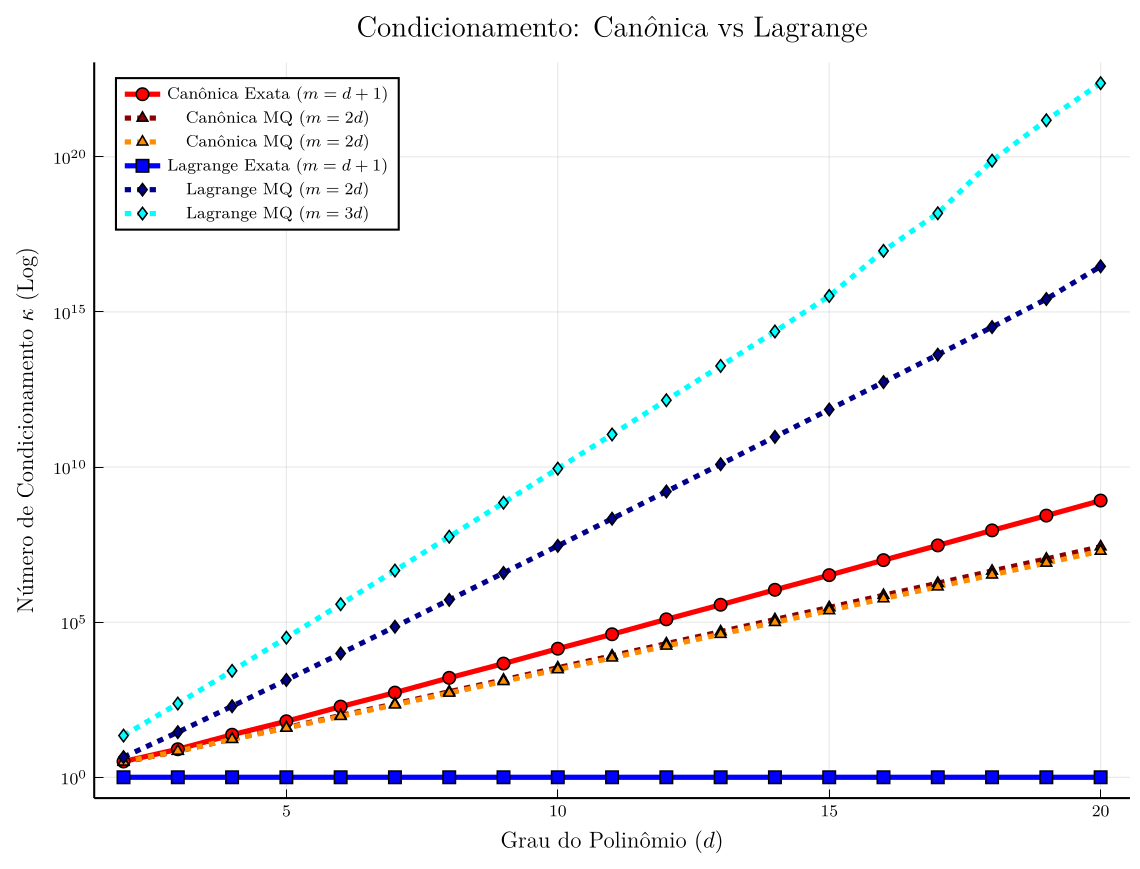

In [120]:
function plot_comparison_bases(d_max=20)
    degrees = 2:d_max
    
    cond_can_exato = Float64[]
    cond_can_2d   = Float64[]
    cond_can_3d = Float64[]

    cond_lag_exato = Float64[]
    cond_lag_2d    = Float64[]
    cond_lag_3d    = Float64[]
    
    for d in degrees
        X_exato = range(-1.0, 1.0, length=d+1)
        X_2d   = range(-1.0, 1.0, length=2d)
        X_3d   = range(-1.0, 1.0, length=3d)
        
        push!(cond_can_exato, cond(matrix_vandermonde(X_exato, d)))
        push!(cond_can_2d,    cond(matrix_vandermonde(X_2d, d)))
        push!(cond_can_3d,    cond(matrix_vandermonde(X_3d, d)))       
        
        push!(cond_lag_exato, cond(matrix_lagrange(X_exato, d)))
        push!(cond_lag_2d,    cond(matrix_lagrange(X_2d, d)))
        push!(cond_lag_3d,    cond(matrix_lagrange(X_3d, d)))

    end
    
    p = plot(title="Condicionamento: Canônica vs Lagrange",
             xlabel=L"\text{Grau do Polinômio }(d)",
             ylabel=L"\text{Número de Condicionamento }\kappa \text{ (Log)}",
             yscale=:log10, 
             legend=:topleft,
             grid=true,
             size=(800, 600),
             margin=6Plots.mm)
             
    plot!(p, degrees, cond_can_exato, label=L"\text{Canônica Exata }(m=d+1)", lw=2.5, color=:red, marker=:circle)
    plot!(p, degrees, cond_can_2d,    label=L"\text{Canônica MQ }(m=2d)", lw=2.5, color=:darkred, ls=:dash, marker=:utriangle)
    plot!(p, degrees, cond_can_3d,    label=L"\text{Canônica MQ }(m=2d)", lw=2.5, color=:darkorange, ls=:dash, marker=:utriangle)
    
    plot!(p, degrees, cond_lag_exato, label=L"\text{Lagrange Exata }(m=d+1)", lw=2.5, color=:blue, marker=:square)
    plot!(p, degrees, cond_lag_2d,    label=L"\text{Lagrange MQ }(m=2d)", lw=2.5, color=:darkblue, ls=:dash, marker=:diamond)
    plot!(p, degrees, cond_lag_3d,    label=L"\text{Lagrange MQ }(m=3d)", lw=2.5, color=:cyan, ls=:dash, marker=:diamond)
    
    return p
end

plot_comparison_bases(20)

Ou seja, quando $m = d+1$, utilizar a matriz na base de Lagrange é muito mais eficiente, pois precisamos de apenas $\approx d+1$ operações para construir a matriz identidade, e ela possui condicionamento 1, enquanto calcular $L_X$ na base canônica continua sendo $O(md)$ e o condicionamento cresce exponencialmente com $d$. Entretanto, percebe-se que quando $m > d+1$, o condicionamento da matriz de base Lagrange cresce mais rápido em função de $d$.

# Questão 3. Interpolação e Extrapolação

## Letra (a):

Qual o posto da aplicação composta $L_Y\circ R_{X,d}$?

Como foi visto na questão 2 letra (a), $(R_{X,d}\circ L_X)(p) = p$, para todo $p \in \mathcal P_d$. Logo, $R_{X,d}$ é sobrejetora (gera todo o espaço $\mathcal P_d$), o que implica que o posto de $L_Y \circ R_{X,d}$ é simplesmente o posto de $L_Y:\mathcal P_d \to \mathbb R^n$. Como foi visto na letra (d) da questão 1, $\text{rank}(L_Y) = \min\left\{n, d+1\right\}$.

## Letra (b):
Explique porque a composta acima não depende da base escolhida para $\mathcal P_d$.

Por que a matriz não depende da base? A aplicação recebe um conjunto de pontos $b = (b_{1}, ..., b_{m})$, calcula, através de $R_{X, d}$, o polinômio $p$ de grau d que melhor se ajusta aos pontos de $b$. Depois, através de $L_{Y}$, avalia $p$ nos pontos $Y = (y_{1}, ..., y_{n})$, retornando $(p(y_{1}), ..., p(y_{n}))$. Como $p(x)$ tem o mesmo valor independente da base em que $p$ está representado, tanto a entrada quanto a saída de $L_{Y} \circ R_{X, d}$ serão a mesma, qualquer seja a base utilizada. O polinômio é "engolido" dentro da aplicação, ele serve apenas de passo intermediário e tem a mesma saída seja qual for a forma como está representado.

Matematicamente, seja $V_Y$, $V_{X}^\dagger$ a matriz de $L_{Y}$ e $R_{X, d}$ na base canônica, respectivamente. Então a matriz de $L_Y \circ R_{X, d}$ é $V_YV_X^\dagger$. Após uma mudança de base do polinômio, $V_X^\dagger$ vira $P^{-1}V_X^\dagger$ para a matriz de mudança de base $P$, pois $V_X^\dagger$ vai retornar o polinômio na canônica, e $P^{-1}$ transforma-o da canônica para outra base. $V_Y$ recebe um polinômio na base canônica e retorna este avaliado em um conjunto de pontos. Por isso, antes da avaliação precisamos converter o polinômio da outra base para a canônica, e isso é feito multiplicando à direita por $P$. Então a matriz na outra base fica $$(V_YP)(P^{-1}V_X^\dagger) = V_YV_X^\dagger$$ Então, a matriz independe da base, como queríamos demonstrar.

OBS: Importante destacar que a base dos polinômios de saída $R_{X, d}$ deve ser a mesma de entrada de $L_{Y}$. Ou seja, $R_{X, d}$ retorna um polinômio na base $\mathbb{X}$, enquanto $L_Y$ recebe um polinômio na base $\mathbb{X}$ e retorna o valor dele nos pontos $Y$. Quando fazemos $V_YV_X^\dagger$, é natural pensar em usar a base de "lagrande" para que tanto $V_X$ quanto $V_Y$ tenham um bloco $(d + 1)\times(d + 1)$ identidade, o que é um erro pois as bases de lagrange para $X$ e para $Y$ são diferentes. 

## Letra (c):

Em que sentido esta composta é uma aplicação de interpolação?

Vamos entender melhor o que a aplicação $L_{Y} \circ R_{X, d}$ está fazendo. Ela pega um conjunto de pontos $b = (b_{1}, ..., b_{m})$, calcula o polinômio de grau d que melhor se ajusta aos pontos. Com esse polinômio em mãos, avaliamos ele nos pontos $Y = (y_{1}, ..., y_{n})$. No fundo, estamos vendo como um polinômio com certo comportamento em alguns pontos, é em outros. Para efeito de entendimento, vamos dar um exemplo simples:

Bernardo e seu irmão estavam observando um carro, e decidiram anotar a posição do carro em certos instantes de tempo. Começando no instante t = 0 e no ponto s = 0, anotou, no tempo t = 1s, 2s, 3s, ..., 10s quantos metros o carro se deslocou. Com isso, eles obteram uma amostra de pontos. Não satisfeitos, queriam calcular a posição do carro em qualquer instante de tempo entre 0s e 10s. Eles presumiram que usar a aproximação polinômial poderia ser uma boa ideia. Após alguma discussão, chegaram a conclusão de que não precisam calcular o polinômio diretamente. Melhor, basta criar a aplicação $L_{Y} \circ R_{X, d}$, com $Y$ os instantes de tempo desejados. Assim, com apenas alguns dados, Bernardo e seu irmão serão capazes de saber com boa precisão onde o carro estava em $\frac{1}{2}$, $e$, ou até mesmo $\pi^{2}$ segundos.

Compreendido isso, eis a pergunta: como isso se relaciona com interpolação? Tudo! Interpolação é a ideia de estimar valores desconhecidos dentro de um intervalo com dados conhecidos. Ou seja, temos $n$ dados dentro de $[-1, 1]$ e queremos "preencher as lacunas faltando". Nesse sentido, $L_{Y} \circ R_{X, d}$ é uma interpolação. Você tem um polinômio que, nos pontos $X = (x_{1}, ..., x_{m})$ são tais que $(p(x_{1}), ..., p(x_{m})) \cong (b_{1}, ..., b_{m})$, e queremos preencher as lacunas, saber quanto vale $p(y)$ para $y$ desejados (Lembre-se que não é preciso calcular $p$ diretamente)

## Letra (d):

Escolha alguns valores de $m$, $n$ e $d$ e calcule os valores singulares da composta, usando
como intermediárias tanto a base canônica quanto a base dos polinômios interpoladores de
Lagrange. Qual a diferença entre as matrizes calculadas?

In [121]:
using Printf

function matrix_lagrange_cruzada(Z, X_base, d)
    n_pts = length(Z)
    M = zeros(Float64, n_pts, d + 1)

    for j in 1:(d + 1)
        D = denominator_lagrange(X_base, j, d) 
        
        for i in 1:n_pts
            M[i, j] = lagrange_base_eval(X_base, Z[i], j, d, D) 
        end
    end

    return M
end

function questao_3d(m_valores, n_valores, d_valores)
    for m in m_valores
        for n in n_valores
            for d in d_valores
                
                X = range(-1.0, 1.0, length=m)
                Y = range(-1.0, 1.0, length=n)

                println("\n============================================================")
                @printf("CENÁRIO: Grau d = %d | Pontos X (m) = %d | Pontos Y (n) = %d\n", d, m, n)
                println("============================================================")

                V_X = matrix_vandermonde(X, d)
                V_Y = matrix_vandermonde(Y, d)
                C_can = V_Y * pinv(V_X) 
                sv_can = svdvals(C_can)

                X_base = X[1:d+1] 
                A_X = matrix_lagrange(X, d)
                A_Y = matrix_lagrange_cruzada(Y, X_base, d)
                C_lag = A_Y * pinv(A_X)
                sv_lag = svdvals(C_lag)

                println("Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa")
                println("-----------------------------------------------------------------")
                
                for k in 1:(d+1)
                    if k <= 2 || k >= d
                        diff_rel = abs(sv_can[k] - sv_lag[k]) / (abs(sv_lag[k]) + 1e-16)
                        @printf("  %2d   | %.8e | %.8e |  %.2e\n", k, sv_can[k], sv_lag[k], diff_rel)
                    elseif k == 3
                        println("  ...  | ...                | ...                |  ...")
                    end
                end
                
                @printf("=> Norma ||C_can - C_lag||:           %.2e\n", norm(C_can - C_lag))
            end
        end
    end
end

m_testes = [35, 50, 65]
n_testes = [80, 95, 100]
d_testes = [4, 16, 32]

questao_3d(m_testes, n_testes, d_testes)


CENÁRIO: Grau d = 4 | Pontos X (m) = 35 | Pontos Y (n) = 80
Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa
-----------------------------------------------------------------
   1   | 1.52482507e+00 | 1.52482507e+00 |  3.50e-13
   2   | 1.52444012e+00 | 1.52444012e+00 |  2.45e-12
  ...  | ...                | ...                |  ...
   4   | 1.41111882e+00 | 1.41111882e+00 |  1.39e-11
   5   | 1.36308887e+00 | 1.36308887e+00 |  3.49e-12
=> Norma ||C_can - C_lag||:           8.10e-11

CENÁRIO: Grau d = 16 | Pontos X (m) = 35 | Pontos Y (n) = 80
Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa
-----------------------------------------------------------------
   1   | 2.66161888e+00 | 2.65849574e+00 |  1.17e-03
   2   | 2.23769540e+00 | 2.24077208e+00 |  1.37e-03
  ...  | ...                | ...                |  ...
  16   | 1.00843112e+00 | 1.00806376e+00 |  3.64e-04
  17   | 1.00508175e+00 | 1.00532631e+00 |  2.43e-04
=> Norma ||C_can - C_lag||:     

Percebe-se que a diferença entre as matrizes (medida pela norma da diferença) aparenta ser proporcional ao grau do polinômio de aproximação. É importante ressaltar a implementação da função 
`matrix_lagrange_cruzada`, que como foi mencionado em uma observação na letra (b), a matriz correspondente a $L_Y$ não terá na maioria das vezes um bloco $(d+1)\times (d+1)$ da identidade, então é preciso avaliar os polinômios da base Lagrange em cada ponto novo $y_j$.

Obtivemos um resultado curioso: Os valores singulares das duas matrizes diferem na casa dos $10^{-5}$ para $d = 32$, $10^{-12}$ para $d = 4$ e $10^{-4}$ para $d = 16$. Para a norma da diferença, temos valores na casa dos $10^{+2}$, $10^{-2}$, $10^{-11}$ para $d = 32, 16$ e $4$, respectivamente. Ou seja, os testes sugerem que as matrizes são iguais! Isso era esperado, pois no item $b)$ provamos matematicamente que a aplicação $L_{Y} \circ R_{X, d}$ tem a mesma matriz para a base canônica, a de lagrange, ou em qualquer base de polinômios. O que ocorre é que, quando calculamos computacionalmente, erros numéricos acontecem. Dependendo de quão bem condicionada a matriz é, esses erros não são muito significantes e podemos confiar nos resultados obtidos. Entretanto, vemos a tendência do erro aumentar exponencialmente com $d$, se tornando problemático para $d$'s grandes. No próximo item, exploraremos graficamente o aumento do condiconamento quando $d \to \infty$

## Letra (e):

Qual o condicionamento da composta $L_Y\circ R_{X,d}$? Você pode fazer $n \to \infty$ sem prejudicar o condicionamento? E $n\to \infty$ e $d \to\infty$?

Como foi mostrado na letra (a), $\text{rank\,}(L_Y\circ R_{X,d}) = \min\left\{n, d+1\right\}$. Como estamos assumindo que $n \geq d+1$ (efetivamente estamos assumindo $n \geq m$), temos que o posto dessa composição será $d+1$. Logo, o condicionamento da composta é
$$\kappa(C) := \kappa(L_Y \circ R_{X,d}) = \frac {\sigma_1}{\sigma_{d+1}},$$
onde $(\sigma_i)$ são os valores singulares em ordem decrescente de $C$, $\sigma_i := 0$ para $i > d+1$. 

É importante calcular o condicionamento dessa forma, pois se apenas aplicássemos algo como `cond(C)` para calculá-lo, erros numéricos iriam explodi-lo. De fato, se houvesse um resquício na diagonal da matriz de valores singulares de algum número muito perto de zero (como $10^{-16}$, por exemplo), `cond(C)` iria executar uma conta do tipo
$$\frac {\sigma_1} {10^{-16}} = \text{muito grande.}$$


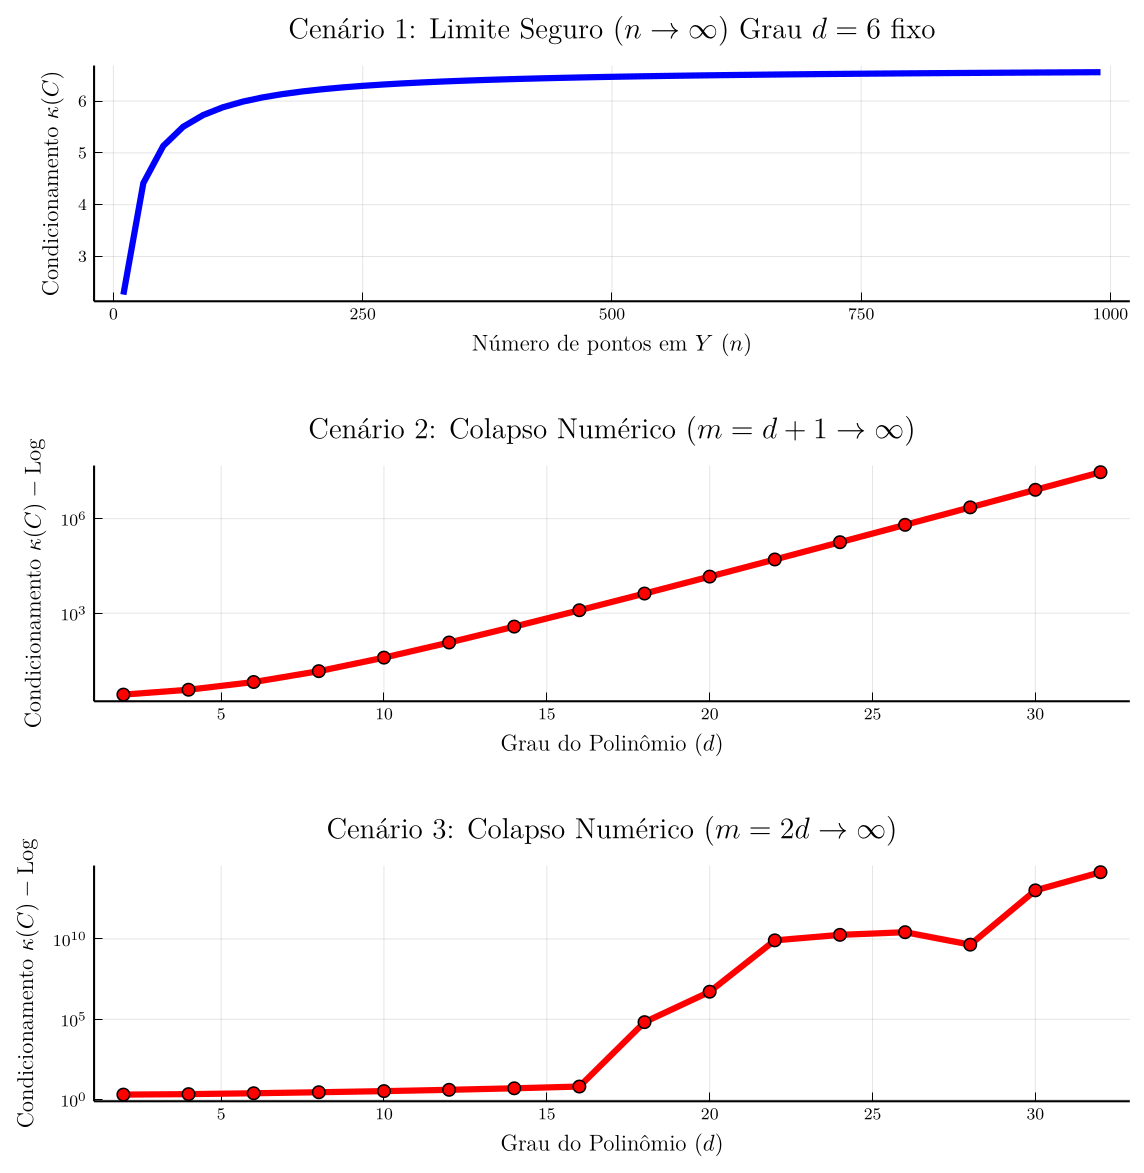

In [ ]:
function visualizar_limites()
    d_fixo = 6
    
    m_fixo = d_fixo + 1 
    
    X_fixo = range(-1.0, 1.0, length=m_fixo)
    X_base_fixo = X_fixo[1:d_fixo+1]
    
    A_X_fixo = matrix_lagrange(X_fixo, d_fixo)
    inv_A_X = pinv(A_X_fixo)

    n_vals = 10:20:1000 
    cond_n = Float64[]

    for n in n_vals
        Y = range(-1.0, 1.0, length=n)
        A_Y = matrix_lagrange_cruzada(Y, X_base_fixo, d_fixo)
        
        C = A_Y * inv_A_X
        
        sv_C = svdvals(C)
        cond_efetivo = sv_C[1] / sv_C[d_fixo + 1] 
        push!(cond_n, cond_efetivo)
    end

p1 = plot(n_vals, cond_n,
          title  = latexstring("Cenário 1: Limite Seguro ", L"(n\to\infty)", "\nGrau ", L"d=6", " fixo"),
          xlabel = latexstring("Número de pontos em  ", L"Y\,\,(n)"),
          ylabel = latexstring("Condicionamento ", L"\kappa(C)"),
          lw=3, 
          color=:blue, 
          legend=false,
          grid=true, 
          margin=6Plots.mm)

    # d \to \infty e n \to \infty
    d_vals = 2:2:32
    cond_d_1 = Float64[]
    cond_d_2 = Float64[]

    n_grande = 1000 
    Y_grande = range(-1.0, 1.0, length=n_grande)

    for d in d_vals
        m = d+1
        X = range(-1.0, 1.0, length=m)
        X_base = X[1:d+1]

        A_X = matrix_lagrange(X, d)
        A_Y = matrix_lagrange_cruzada(Y_grande, X_base, d)
        
        C = A_Y * pinv(A_X)
        
        sv_C = svdvals(C)
        cond_efetivo = sv_C[1] / sv_C[d + 1]
        push!(cond_d_1, cond_efetivo)
    end

    p2 = plot(d_vals, cond_d_1,
              title=L"\text{Cenário 2: Colapso Numérico }(m = d +1\to \infty)",
              xlabel=L"\text{Grau do Polinômio }(d)",
              ylabel=L"\text{Condicionamento }\kappa(C) - \text{Log}",
              yscale=:log10, 
              lw=3, color=:red, marker=:circle, legend=false,
              grid=true, margin=6Plots.mm)

    for d in d_vals
        m = 2d
        X = range(-1.0, 1.0, length=m)
        X_base = X[1:d+1]

        A_X = matrix_lagrange(X, d)
        A_Y = matrix_lagrange_cruzada(Y_grande, X_base, d)
        
        C = A_Y * pinv(A_X)
        
        sv_C = svdvals(C)
        cond_efetivo = sv_C[1] / sv_C[d + 1]
        push!(cond_d_2, cond_efetivo)
    end
    p3 = plot(d_vals, cond_d_2,
              title=L"\text{Cenário 3: Colapso Numérico }(m = 2d \to \infty)",
              xlabel=L"\text{Grau do Polinômio }(d)",
              ylabel=L"\text{Condicionamento }\kappa(C) - \text{Log}",
              yscale=:log10, 
              lw=3, color=:red, marker=:circle, legend=false,
              grid=true, margin=6Plots.mm)

    grafico_final = plot(p1, p2, p3, layout=(3, 1), size=(800, 800))
    
    display(grafico_final)
    return grafico_final
end

visualizar_limites();

Após observar o primeiro plot, percebe-se que quando $n\to \infty$, o condicionamento eventualmente atinge um teto e se mantém estável se $d$ permanecer fixo. Já o segundo e terceiro plot dão a entender que quando fazemos $d$ aumentar, o condicionamento aparenta crescer de forma exponencial sem sinal de parada.

De fato, aumentar somente $n$ não prejudica o condicionamento de $C$. O operador $R_{X,d}$ constrói o polinômio com base nos $m$ pontos (que são fixos) originais, e tudo que estamos fazendo é adicionar mais pontos de avaliação no operador $L_Y$.

## Letra (f):

Refaça os exercícios (c) e (d) substituindo $X$ pelo conjunto dos "pontos de Chebyshev" $x_i = \cos\left(\frac {2i - 1}{2m}\pi\right)$.

$\textbf{c)}$
Quando mudamos a distribuição dos pontos de uma uniforme para os de Chebyshev, ainda teremos uma aplicação de interpolação: Tranforma os dados de $X$ em um polinômio $p$ de grau $d$, e o avalia em $Y$. O que muda, entretanto, é o comportamento da interpolação para graus maiores. Um erro muito comum de se pensar, é que quando aumentamos o grau $d$ do polinômio, teremos uma aproximação cada vez melhor da nossa função. O que ocorre, entretanto, é que quando o grau cresce, o polinômio adquire tendências explosivas, sobretudo nas bordas. Dentro de um intervalo fechado, talvez podemos aproximar muito bem uma função quando aumentamos o grau. Mas essa melhora é, digamos, extremamente artificial, como veremos mais adiante que ao pisar fora desse intervalo, o comportamento fica completamente bizarro, com oscilações violentas. Mas então esse é um problema para quando estivermos fazendo extrapolação. A pergunta é: Por que Chebyshev é melhor que a uniforme na interpolação? Pensando de forma intuitiva, quando aumentamos o grau, temos oscilações cada vez maiores na borda. Mas essas oscilações também aparecem dentro do intervalo. Quando usamos a distribuição uniforme, os pontos perto da borda estão relativamente "longes" um do outro, e entre dois pontos ocorre essas oscilações. Nos pontos de Chebyshev, entretanto, pontos perto da borda estão muito próximos, evitando que o polinômio tenha "espaço" para agir loucamente já dentro do intervalo. Por isso, os pontos de Chebyshev "anulam" o ruído do caos advindo de fora do intervalo, enquanto o uniformes deixam os ruídos transbordarem para dentro do intervalo.


In [123]:
function chebyshev(m, d)
    X_m = sort([cos(pi * (2i - 1) / (2 * m)) for i in 1:m])
    
    idx_base = round.(Int, range(1, m, length=d+1))
    
    X_base = X_m[idx_base]
    X_resto = deleteat!(copy(X_m), idx_base)

    return vcat(X_base, X_resto)
end

function questao_3f(m_valores, n_valores, d_valores)
    for m in m_valores
        for n in n_valores
            for d in d_valores
                
                X = chebyshev(m, d)
                Y = range(-1.0, 1.0, length=n)

                println("\n============================================================")
                @printf("CENÁRIO: Grau d = %d | Pontos X (m) = %d | Pontos Y (n) = %d\n", d, m, n)
                println("============================================================")

                V_X = matrix_vandermonde(X, d)
                V_Y = matrix_vandermonde(Y, d)
                C_can = V_Y * pinv(V_X) 
                sv_can = svdvals(C_can)

                X_base = X[1:d+1] 
                A_X = matrix_lagrange(X, d)
                A_Y = matrix_lagrange_cruzada(Y, X_base, d)
                C_lag = A_Y * pinv(A_X)
                sv_lag = svdvals(C_lag)

                println("Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa")
                println("-----------------------------------------------------------------")
                
                for k in 1:(d+1)
                    if k <= 2 || k >= d
                        diff_rel = abs(sv_can[k] - sv_lag[k]) / (abs(sv_lag[k]) + 1e-16)
                        @printf("  %2d   | %.8e | %.8e |  %.2e\n", k, sv_can[k], sv_lag[k], diff_rel)
                    elseif k == 3
                        println("  ...  | ...                | ...                |  ...")
                    end
                end
                
                @printf("=> Norma ||C_can - C_lag||:           %.2e\n", norm(C_can - C_lag))
            end
        end
    end
end

m_testes = [35, 50, 65]
n_testes = [80, 95, 100]
d_testes = [4, 16, 32]

questao_3f(m_testes, n_testes, d_testes)


CENÁRIO: Grau d = 4 | Pontos X (m) = 35 | Pontos Y (n) = 80
Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa
-----------------------------------------------------------------
   1   | 1.84864981e+00 | 1.84864981e+00 |  9.61e-16
   2   | 1.67920689e+00 | 1.67920689e+00 |  1.06e-15
  ...  | ...                | ...                |  ...
   4   | 9.98390518e-01 | 9.98390518e-01 |  7.78e-16
   5   | 9.34039232e-01 | 9.34039232e-01 |  9.51e-16
=> Norma ||C_can - C_lag||:           4.82e-15

CENÁRIO: Grau d = 16 | Pontos X (m) = 35 | Pontos Y (n) = 80
Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa
-----------------------------------------------------------------
   1   | 1.87930130e+00 | 1.87930130e+00 |  4.47e-13
   2   | 1.86654437e+00 | 1.86654437e+00 |  1.28e-12
  ...  | ...                | ...                |  ...
  16   | 8.07563939e-01 | 8.07563939e-01 |  3.26e-12
  17   | 7.90836544e-01 | 7.90836544e-01 |  2.91e-13
=> Norma ||C_can - C_lag||:     

É importante ressaltar como a função `chebyshev()` funciona. Nós geramos os pontos em ordem, porém rearranjamos os $d+1$ pontos no conjunto igualmente espaçados, os colocando no início da lista. Isso é essencial para conseguir usufruir das vantagens em utilizar os pontos de Chebyshev em vez de pontos uniformes.

$\textbf{d)}$
Os resultados obtidos usando os pontos de Chebyshev são muito mais precisos do que os resultados com a uniforme. Os valores singulares passaram de uma precisão na casa de $10^{-6}$ para $10^{-13}$, enquanto a norma foi de $10^{-4}$ para $10^{-11}$. Isso ocorre por que, como já explicado antes, os pontos de Chebyshev controlam melhor o mau comportamento polinomial nas bordas do que a Uniforme. Isso se transmite para a estabilidade dos algoritmos computacionais.

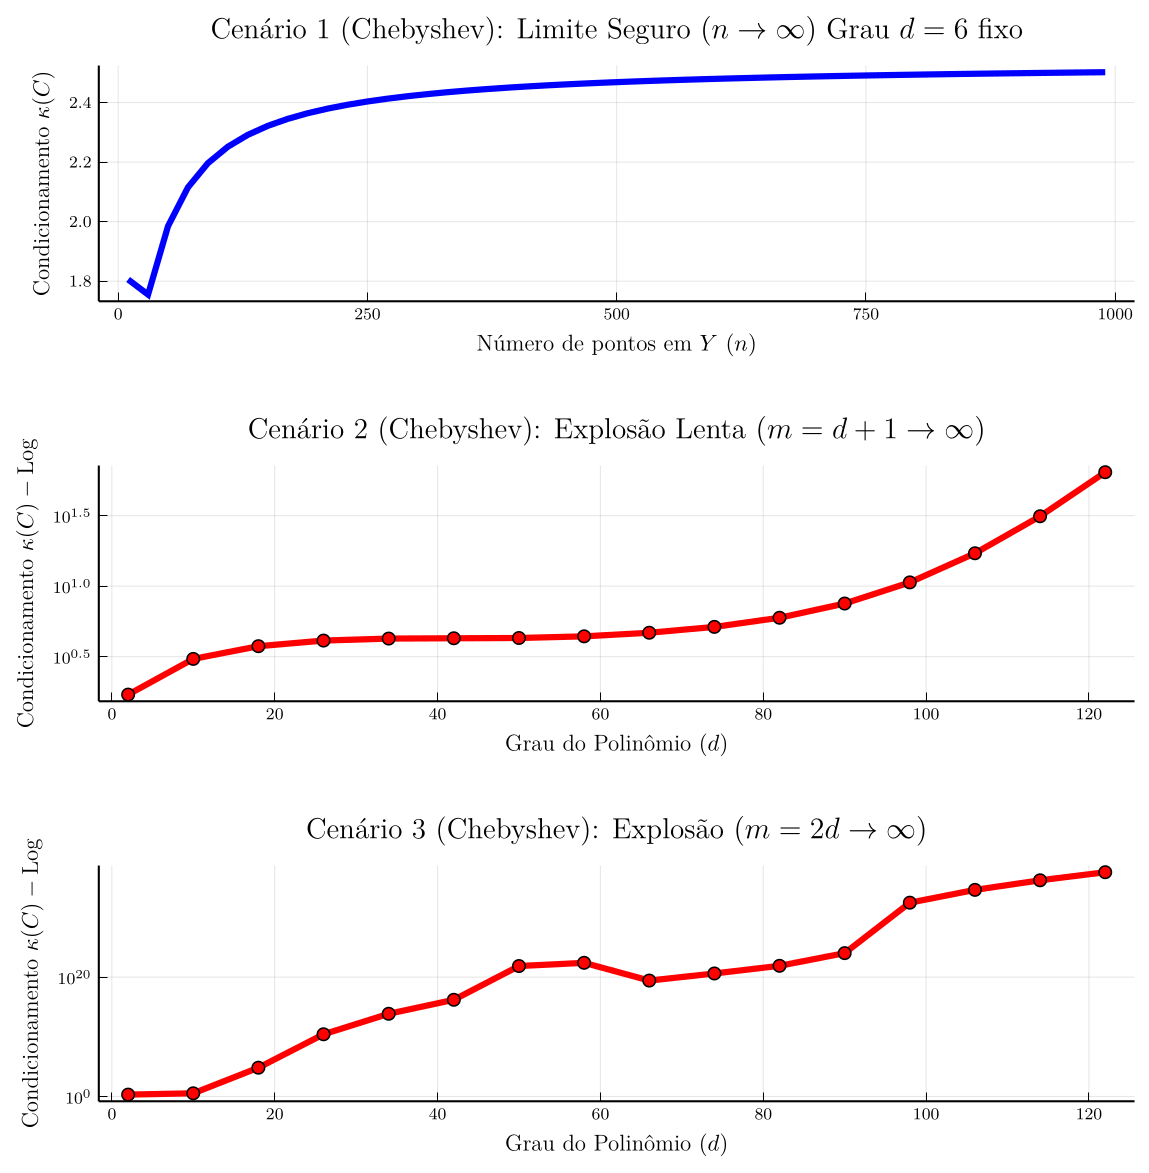

In [124]:
function visualizar_limites_chebyshev()
    d_fixo = 6
    
    m_fixo = d_fixo + 1 
    
    X_fixo = chebyshev(m_fixo, d_fixo)
    X_base_fixo = X_fixo[1:d_fixo+1]
    
    A_X_fixo = matrix_lagrange(X_fixo, d_fixo)
    inv_A_X = pinv(A_X_fixo)

    n_vals = 10:20:1000 
    cond_n = Float64[]

    for n in n_vals
        Y = range(-1.0, 1.0, length=n)
        A_Y = matrix_lagrange_cruzada(Y, X_base_fixo, d_fixo)
        
        C = A_Y * inv_A_X
        
        sv_C = svdvals(C)
        cond_efetivo = sv_C[1] / sv_C[d_fixo + 1] 
        push!(cond_n, cond_efetivo)
    end

p1 = plot(n_vals, cond_n,
          title  = latexstring("Cenário 1 (Chebyshev): Limite Seguro ", L"(n\to\infty)", "\nGrau ", L"d=6", " fixo"),
          xlabel = latexstring("Número de pontos em  ", L"Y\,\,(n)"),
          ylabel = latexstring("Condicionamento ", L"\kappa(C)"),
          lw=3, 
          color=:blue, 
          legend=false,
          grid=true, 
          margin=6Plots.mm)

    # d \to \infty e n \to \infty
    d_vals = 2:8:128
    cond_d_1 = Float64[]
    cond_d_2 = Float64[]

    n_grande = 1000 
    Y_grande = range(-1.0, 1.0, length=n_grande)

    for d in d_vals
        m = d+1
        X = chebyshev(m, d)
        X_base = X[1:d+1]

        A_X = matrix_lagrange(X, d)
        A_Y = matrix_lagrange_cruzada(Y_grande, X_base, d)
        
        C = A_Y * pinv(A_X)
        
        sv_C = svdvals(C)
        cond_efetivo = sv_C[1] / sv_C[d + 1]
        push!(cond_d_1, cond_efetivo)
    end

    p2 = plot(d_vals, cond_d_1,
              title=L"\text{Cenário 2 (Chebyshev): Explosão Lenta }(m = d +1\to \infty)",
              xlabel=L"\text{Grau do Polinômio }(d)",
              ylabel=L"\text{Condicionamento }\kappa(C) - \text{Log}",
              yscale=:log10, 
              lw=3, color=:red, marker=:circle, legend=false,
              grid=true, margin=6Plots.mm)

    for d in d_vals
        m = 2d
        X = range(-1.0, 1.0, length=m)
        X_base = X[1:d+1]

        A_X = matrix_lagrange(X, d)
        A_Y = matrix_lagrange_cruzada(Y_grande, X_base, d)
        
        C = A_Y * pinv(A_X)
        
        sv_C = svdvals(C)
        cond_efetivo = sv_C[1] / sv_C[d + 1]
        push!(cond_d_2, cond_efetivo)
    end
    p3 = plot(d_vals, cond_d_2,
              title=L"\text{Cenário 3 (Chebyshev): Explosão }(m = 2d \to \infty)",
              xlabel=L"\text{Grau do Polinômio }(d)",
              ylabel=L"\text{Condicionamento }\kappa(C) - \text{Log}",
              yscale=:log10, 
              lw=3, color=:red, marker=:circle, legend=false,
              grid=true, margin=6Plots.mm)

    grafico_final = plot(p1, p2, p3, layout=(3, 1), size=(800, 800))
    
    display(grafico_final)
    return grafico_final
end

visualizar_limites_chebyshev();

Aqui a diferença importante está no segundo plot,

$\textbf{e)}$ Quando $n \to \infty$, o condicionamento se estabiliza para um valor inferior à uniforme. Quando $n, d \to \infty$ e $m = d + 1$, o condicionamento cresce, mas extremamente mais lento que a uniforme. Enquanto na uniforme temos $\approx 10^{6}$ para $d = 30$, temos $\approx 10^{1.5}$ para $d = 120$ com Chebyshev. 

## Letra (g):

$\textbf{Extrapolação 1.}$ Considere $X = \text{linspace}(-1, 1, m)$, e $Y = \text{linspace}(-1.5, 1.5, n)$. O que acontece agora?

EXTRAPOLAÇÃO 1 | m=30, n=45, Grau d=16
κ(C) Canônica: 1.82e+06
κ(C) Lagrange: 1.82e+06
Norma ||C_can - C_lag||: 2.58e+01


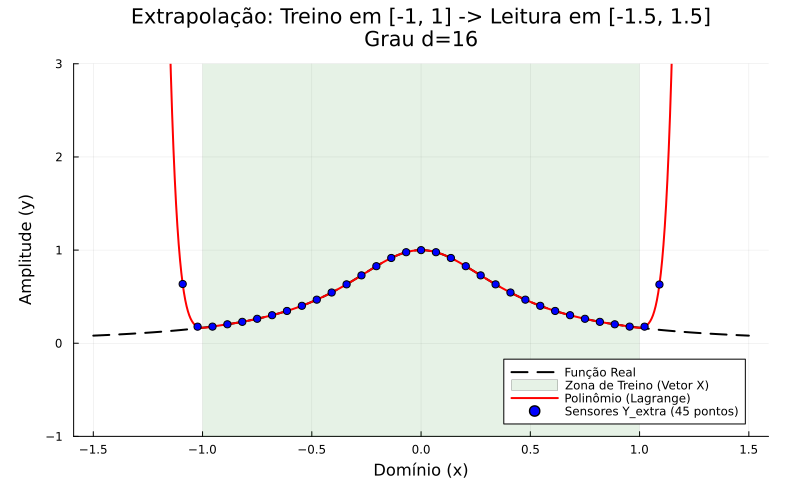

In [125]:
gr()

function testar_extrapolacao_1(X, n, d)
    m = length(X)
    X_base = X[1:d+1]

    Y_extra  = range(-1.5, 1.5, length=n)

    A_X = matrix_lagrange(X, d)
    A_Y_extra = matrix_lagrange_cruzada(Y_extra, X_base, d)
    C_lag = A_Y_extra * pinv(A_X)
    sv_lag = svdvals(C_lag)
    cond_lag = sv_lag[1] / sv_lag[d+1]

    V_X = matrix_vandermonde(X, d)
    V_Y_extra = matrix_vandermonde(Y_extra, d)
    C_can = V_Y_extra * pinv(V_X)
    sv_can = svdvals(C_can)
    cond_can = sv_can[1] / sv_can[d+1]
    
    erro_matrizes = norm(C_can - C_lag)

    println("======================================================")
    @printf("EXTRAPOLAÇÃO 1 | m=%d, n=%d, Grau d=%d\n", m, n, d)
    println("======================================================")
    @printf("κ(C) Canônica: %.2e\n", cond_can)
    @printf("κ(C) Lagrange: %.2e\n", cond_lag)
    @printf("Norma ||C_can - C_lag||: %.2e\n", erro_matrizes)

    f(x) = 1.0 / (1.0 + 5*x^2) 
    b_X = f.(X)                     
    
    Y_proj = C_lag * b_X 
    
    X_plot = range(-1.5, 1.5, length=500)
    Y_real = f.(X_plot)
    C_plot = matrix_lagrange_cruzada(X_plot, X_base, d) * pinv(A_X)
    Y_plot_proj = C_plot * b_X

    p = plot(X_plot, Y_real, label="Função Real", lw=2, color=:black, ls=:dash,
             title="Extrapolação: Treino em [-1, 1] -> Leitura em [-1.5, 1.5]\nGrau d=$d",
             xlabel="Domínio (x)", ylabel="Amplitude (y)", 
             ylims=(-1.0, 3.0), # Travamos o Y para focar no detalhe
             grid=true, size=(800, 500), margin=6Plots.mm)
             
    vspan!(p, [-1.0, 1.0], color=:green, alpha=0.1, label="Zona de Treino (Vetor X)")
    
    plot!(p, X_plot, Y_plot_proj, label="Polinômio (Lagrange)", lw=2, color=:red)
    
    scatter!(p, Y_extra, Y_proj, label="Sensores Y_extra ($n pontos)", 
             color=:blue, markershape=:circle, markersize=4)
    
    display(p)
end

m = 30
n = 45
d = 16
X = range(-1.0, 1.0, length=m)

testar_extrapolacao_1(X, n, d)

Aqui escolhemos uma função razoável no intervalo $[-1, 1]$ para tentar interpolar, $f(x) = \frac 1 {1 + 5x^2}$. Apesar do polinômio conseguir ser extremamente preciso no intervalo de "treino" $[-1,1]$, quando tentamos extender o polinômio para fora do domínio, os valores explodem para o infinito. Isso é evidenciado também pelo condicionamento da composta $C = L_Y \circ R_{X,d}$, que cresce ordens de grandeza para $\approx 10^6$, devido a valores muito grandes na matriz $L_Y$. Também há um aumento significativo na diferença entre as matrizes $C_{\text{lag}}$ e $C_{\text{can}}$, que são matematicamente o mesmo objeto, resultado da explosão dos valores de $R_{X,d}\left(\begin{bmatrix} f(x_1) & f(x_2) & \cdots & f(x_{d+1})\end{bmatrix}^T\right)$ (polinômio de lagrange) avaliado em $Y$.

Vale mencionar por que a escolha da função $f(x) = \frac 1 {1 + 5x^2}$. Quando vamos para $\pm \infty$, um polinômio cresce em módulo para $+\infty$. Queremos encontrar uma função simples, que seja bem aproximada por polinômios dentro de um intervalo, mas que o mesmo não aconteça fora. Por isso, como polinômios crescem para cima ou para baixo, é lógico pensar em uma função que se estagna em um valor finito. Para uma função que tende para $0$, $\frac{1}{1 + x^{2}}$. O coeficiente $5$ foi escolhido após o teste com vários coeficientes

## Letra (h):

Adianta usar os pontos de Chebyshev em $X$?

EXTRAPOLAÇÃO 1 | m=30, n=45, Grau d=16
κ(C) Canônica: 1.22e+06
κ(C) Lagrange: 1.22e+06
Norma ||C_can - C_lag||: 3.03e-05


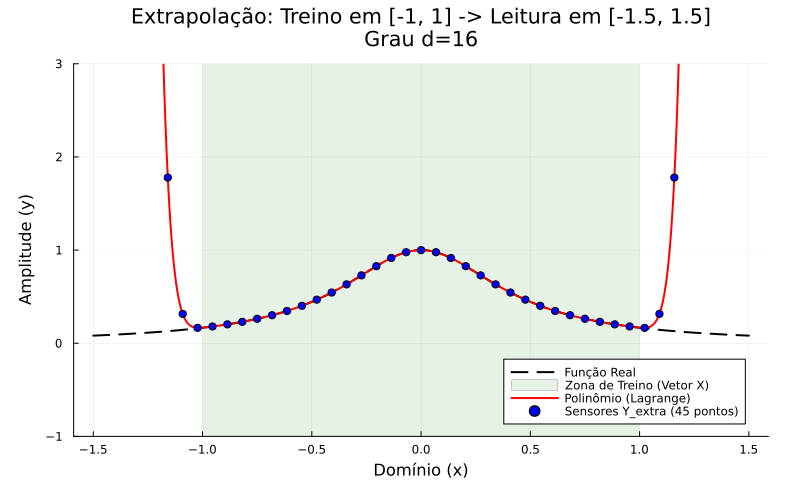

In [126]:
X = chebyshev(m, d)

testar_extrapolacao_1(X, n, d)

A diferença entre as matrizes é menor (provavelmente devido ao fato que dentro do intervalo $[-1,1]$ os pontos de Chebyshev geram uma aproximação muito mais precisa), porém o fenômeno de "explosão" fora do domínio continua acontecendo, evidenciado pelo polinômio visivelmente crescer muito rápido em um intervalo $[-1 - \delta, 1 + \delta]$, com $\delta > 0$ pequeno, além do alto condicionamento de $C$.

## Letra (i):
Considere $X = \text{linspace}(0, 1, m)$, e $Y = \text{linspace}(-1, 0, n)$. O que acontece agora? Adianta usar os pontos de Chebyshev?

EXTRAPOLAÇÃO 2 | Treino [0,1] -> Y [-1,0]
κ(C) Uniformes: 1.35e+14
κ(C) Chebyshev: 8.47e+16


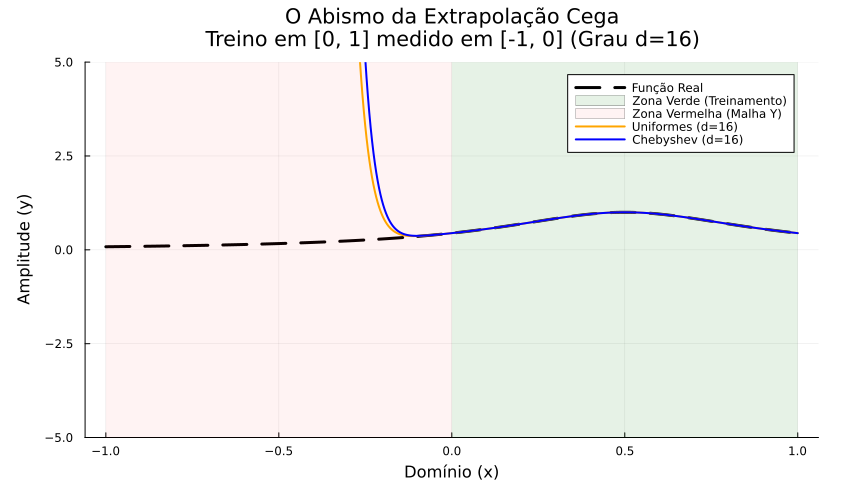

In [127]:
function testar_extrapolacao_2_estendida(m, n, d)
    X_uni = range(0.0, 1.0, length=m)
    X_base_uni = X_uni[1:d+1]

    X_cheb_original = chebyshev(m, d)
    X_cheb = (X_cheb_original .+ 1.0) ./ 2.0 # chebyshev transladado
    X_base_cheb = X_cheb[1:d+1]

    Y_extra = range(-1.0, 0.0, length=n)

    A_X_uni = matrix_lagrange(X_uni, d)
    C_uni = matrix_lagrange_cruzada(Y_extra, X_base_uni, d) * pinv(A_X_uni)
    sv_uni = svdvals(C_uni)
    cond_uni = sv_uni[1] / sv_uni[d+1]

    A_X_cheb = matrix_lagrange(X_cheb, d)
    C_cheb = matrix_lagrange_cruzada(Y_extra, X_base_cheb, d) * pinv(A_X_cheb)
    sv_cheb = svdvals(C_cheb)
    cond_cheb = sv_cheb[1] / sv_cheb[d+1]

    println("======================================================")
    @printf("EXTRAPOLAÇÃO 2 | Treino [0,1] -> Y [-1,0]\n")
    println("======================================================")
    @printf("κ(C) Uniformes: %.2e\n", cond_uni)
    @printf("κ(C) Chebyshev: %.2e\n", cond_cheb)

    f(x) = 1.0 / (1.0 + 5 * (x - 0.5)^2) # Função transladada

    X_plot = range(-1.0, 1.0, length=500)
    Y_real = f.(X_plot)

    C_plot_uni = matrix_lagrange_cruzada(X_plot, X_base_uni, d) * pinv(A_X_uni)
    Y_plot_uni = C_plot_uni * f.(X_uni)

    C_plot_cheb = matrix_lagrange_cruzada(X_plot, X_base_cheb, d) * pinv(A_X_cheb)
    Y_plot_cheb = C_plot_cheb * f.(X_cheb)

    p = plot(X_plot, Y_real, label="Função Real", lw=3, color=:black, ls=:dash,
             title="O Abismo da Extrapolação Cega\nTreino em [0, 1] medido em [-1, 0] (Grau d=$d)",
             xlabel="Domínio (x)", ylabel="Amplitude (y)", 
             ylims=(-5.0, 5.0),
             grid=true, size=(850, 500), margin=6Plots.mm)
             
    vspan!(p, [0.0, 1.0], color=:green, alpha=0.1, label="Zona Verde (Treinamento)")
    vspan!(p, [-1.0, 0.0], color=:red, alpha=0.05, label="Zona Vermelha (Malha Y)")
    
    plot!(p, X_plot, Y_plot_uni, label="Uniformes (d=$d)", lw=2, color=:orange)
    plot!(p, X_plot, Y_plot_cheb, label="Chebyshev (d=$d)", lw=2, color=:blue)
    
    display(p)
end

testar_extrapolacao_2_estendida(30, 45, 16)

O que temos agora é uma explosão maior ainda, devido ao fato de que $Y$ e $X$ possuem interseção "quase vazia" (exceto por um conjunto de medida zero $\left\{0\right\}$). Ambos os pontos geram uma boa aproximação no $[0,1]$, porém agora os pontos de Chebyshev são ainda piores em $[-1,0)$ (a matriz possui condicionamento 100 vezes maior).